## **Project Title - Agricultural Data Analysis for Smart Crop Selection**

**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

**What I did:**
Imported required Python libraries for data analysis and visualization.

**Why it is important:**

**NumPy** → Used for numerical operations

**Pandas** → Helps in loading and handling dataset

**Matplotlib & Seaborn** → Used for creating graphs and visualizations

**%matplotlib inline** → Ensures plots are displayed inside the notebook

This is the standard starting point of any data analysis project.

**Loading Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving simple_changeddemo.csv to simple_changeddemo.csv


In [ ]:
df = pd.read_csv("simple_changeddemo.csv",encoding = 'unicode_escape')

**What I did:**
Loaded the dataset using pandas into a DataFrame.

**Why it is important:**
It allows us to access and manipulate the dataset easily in tabular form for further analysis.

**Basic Data Understanding**

In [ ]:
df.shape

(500, 24)

**What I did:**
Checked the number of rows and columns in the dataset.

**Why it is important:**
Gives an idea about the dataset size and complexity.

In [ ]:
df.head()

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,...,Altitude,Season,Irrigation_Type,Fertilizer_Used,Previous_Crop,Recommended_Crop,Pesticide_Type,Farmer_Experience_Years,Market_Price_Per_Ton,Nitrogen_demo
0,122,55,74,4.54,58.90,Silt,0.77,0.67,25.31,35.15,...,1947,Kharif,Sprinkler,176.38,Wheat,Sugarcane,NaN,NaN,NaN,122
1,112,37,25,7.03,25.98,Sandy,0.66,1.94,31.80,54.80,...,69,Zaid,Canal,180.05,Cotton,Rice,NaN,NaN,NaN,112
2,34,52,39,4.95,27.61,Clay,1.36,2.03,15.78,30.88,...,2049,Kharif,Sprinkler,308.10,Pulses,Barley,NaN,NaN,NaN,34
3,126,35,82,7.14,39.97,Loamy,1.09,0.30,38.23,47.60,...,930,Rabi,Sprinkler,230.54,Cotton,Millet,NaN,NaN,NaN,126
4,91,64,51,8.20,33.97,Sandy,0.70,2.07,10.04,72.42,...,20,Kharif,Rainfed,63.73,Cotton,Wheat,NaN,NaN,NaN,91


**What I did:**
Displayed the first few rows of the dataset.

**Why it is important:**
Helps to quickly understand the structure, column names, and sample data values.

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   N                        500 non-null    int64  
 1   P                        500 non-null    int64  
 2   K                        500 non-null    int64  
 3   Soil_pH                  500 non-null    float64
 4   Soil_Moisture            500 non-null    float64
 5   Soil_Type                500 non-null    object 
 6   Organic_Carbon           500 non-null    float64
 7   Electrical_Conductivity  500 non-null    float64
 8   Temperature              500 non-null    float64
 9   Humidity                 496 non-null    float64
 10  Rainfall                 500 non-null    float64
 11  Sunlight_Hours           495 non-null    float64
 12  Wind_Speed               494 non-null    float64
 13  Region                   500 non-null    object 
 14  Altitude                 5

**What I did:**
Checked data types and non-null values of each column.

**Why it is important:**

Helps detect missing values
Identifies incorrect data types
Important for preprocessing

 **Data Cleaning - Dropping Unecessary columns**

In [ ]:
df.drop(['Pesticide_Type','Farmer_Experience_Years','Market_Price_Per_Ton'], axis=1, inplace=True)

**What I did:**

Removed unnecessary columns (Pesticide_Type, Farmer_Experience_Years, Market_Price_Per_Ton) from the dataset.

 **Why it is important:**
These columns are not useful for the current analysis or prediction task
Removing irrelevant features helps reduce noise in the dataset
Improves model performance and training efficiency
Makes the dataset simpler and more focused on important variables

**axis=1** → means we are dropping columns (not rows)

**inplace=True** → directly modifies the original dataset without creating a copy

**Checking Missing Values - Counts null values in each column**



In [ ]:
pd.isnull(df).sum()

,0
N,0
P,0
K,0
Soil_pH,0
Soil_Moisture,0
Soil_Type,0
Organic_Carbon,0
Electrical_Conductivity,0
Temperature,0
Humidity,4


**What I did:**
Checked null values using .isnull().sum().

**Why it is important:**
Missing values can affect model performance and must be handled properly.

**Handling Missing Values (Imputation)**

In [ ]:
df.fillna({
    'Humidity': df['Humidity'].mean(),
    'Sunlight_Hours': df['Sunlight_Hours'].mean(),
    'Wind_Speed': df['Wind_Speed'].mean()
}, inplace=True)

**What I did:**

Filled missing values in the columns Humidity, Sunlight_Hours, and Wind_Speed using their respective mean values.

**Why it is important:**
Missing values can affect analysis and model performance
Replacing them with the mean keeps the data balanced
Mean is a good choice for numerical data as it represents the average value
Prevents errors during model training

**fillna() **→ used to replace missing values

**df['column'].mean()** → calculates average of that column

**inplace=True** → updates the original dataset directly

In [ ]:
#Rechecking for null values

pd.isnull(df).sum()

,0
N,0
P,0
K,0
Soil_pH,0
Soil_Moisture,0
Soil_Type,0
Organic_Carbon,0
Electrical_Conductivity,0
Temperature,0
Humidity,0


**Rechecking imputed values**

In [ ]:
df.loc[[11,15,26,39], ['Humidity']]

,Humidity
11,60.73881
15,60.73881
26,60.73881
39,60.73881


In [ ]:
df.loc[[0,12,24,34,36], ['Sunlight_Hours']]

,Sunlight_Hours
0,7.865192
12,7.865192
24,7.865192
34,7.865192
36,7.865192


In [ ]:
df.loc[[2,26,36,42,43,48], ['Wind_Speed']]

,Wind_Speed
2,10.726761
26,10.726761
36,10.726761
42,10.726761
43,10.726761
48,10.726761


**Humidity** - **13,17,28,41** (11,15,26,39)

**Sunlight_Hours** - **2,14,26,36,38** (0,12,24,34,36)

**Wind Speed** - 4,28,38,44,45,50 (2,26,36,42,43,48)




In pandas, indexing starts from 0, while in Microsoft Excel rows start from 1.

So if we made Excel row 13 null, pandas will treat it as index 11 or 12 depending on header.

Our dataset has a header row, so the mapping becomes:
13	-> 11 ;
17	-> 15 ;
28	-> 26 ;
41	-> 39 ;

In [ ]:
df[['Humidity','Sunlight_Hours','Wind_Speed']].head(51)

,Humidity,Sunlight_Hours,Wind_Speed
0,35.15000,7.865192,5.980000
1,54.80000,4.230000,16.170000
2,30.88000,11.450000,10.726761
3,47.60000,4.710000,4.290000
4,72.42000,11.210000,4.410000
5,42.17000,4.510000,19.280000
6,89.92000,11.750000,10.730000
7,32.90000,4.070000,2.860000
8,38.19000,11.720000,2.440000
9,77.21000,4.500000,19.320000


**Changing Data Type**

In [ ]:
df['Temperature'] = df['Temperature'].astype('int')
df['Rainfall'] = df['Rainfall'].astype('int')
df['Altitude'] = df['Altitude'].astype('int')
df['Soil_Moisture'] = df['Soil_Moisture'].astype('int')

In [ ]:
df[['Temperature','Rainfall','Altitude']].dtypes

,0
Temperature,int64
Rainfall,int64
Altitude,int64


In [ ]:
df.columns

Index(['N', 'P', 'K', 'Soil_pH', 'Soil_Moisture', 'Soil_Type',
       'Organic_Carbon', 'Electrical_Conductivity', 'Temperature', 'Humidity',
       'Rainfall', 'Sunlight_Hours', 'Wind_Speed', 'Region', 'Altitude',
       'Season', 'Irrigation_Type', 'Fertilizer_Used', 'Previous_Crop',
       'Recommended_Crop', 'Nitrogen_demo'],
      dtype='object')

**Renaming Columns**

In [ ]:
df.rename(columns={
    'N': 'Nitrogen',
    'P': 'Phosphorous',
    'K': 'Potassium'
}, inplace=True)

In [ ]:
#Rename Columns

print(df.columns)

Index(['Nitrogen', 'Phosphorous', 'Potassium', 'Soil_pH', 'Soil_Moisture',
       'Soil_Type', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature',
       'Humidity', 'Rainfall', 'Sunlight_Hours', 'Wind_Speed', 'Region',
       'Altitude', 'Season', 'Irrigation_Type', 'Fertilizer_Used',
       'Previous_Crop', 'Recommended_Crop', 'Nitrogen_demo'],
      dtype='object')


In [ ]:
# describe() method returns description of the data in the DataFrame (i.e. count, mean, std, etc)
df.describe()

,Nitrogen,Phosphorous,Potassium,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Nitrogen_demo
count,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,91.876000,48.920000,64.11400,6.481340,34.766000,0.799240,1.566140,24.612000,60.738810,1583.144000,7.865192,10.726761,1198.836000,202.947740,94.462000
std,40.986344,22.821201,32.19556,1.145983,14.275252,0.373037,0.818941,8.712593,17.357249,812.927094,2.288897,5.526234,746.109775,86.786561,49.815859
min,20.000000,10.000000,10.00000,4.510000,10.000000,0.200000,0.100000,10.000000,30.020000,211.000000,4.000000,1.010000,1.000000,50.170000,20.000000
25%,56.750000,30.000000,36.00000,5.467500,22.000000,0.500000,0.885000,17.000000,46.360000,849.000000,5.987500,5.717500,522.750000,128.362500,57.000000
50%,91.000000,51.000000,64.00000,6.490000,36.000000,0.745000,1.610000,24.000000,61.535000,1622.000000,7.720000,11.095000,1246.500000,205.580000,92.500000
75%,128.000000,68.000000,91.25000,7.460000,46.000000,1.115000,2.240000,32.250000,75.472500,2268.750000,9.810000,15.395000,1832.500000,277.712500,128.250000
max,159.000000,89.000000,119.00000,8.490000,59.000000,1.490000,3.000000,39.000000,89.990000,2996.000000,11.960000,19.980000,2498.000000,348.880000,450.000000


**What I did:**
Generated summary statistics for numerical columns.

**Why it is important:**

Helps understand distribution of data
Detects abnormal values
Useful for further analysis

**UNIVARIATE** **ANALYSIS - (Analysis of Single Variable)**

**Crops Distribution**

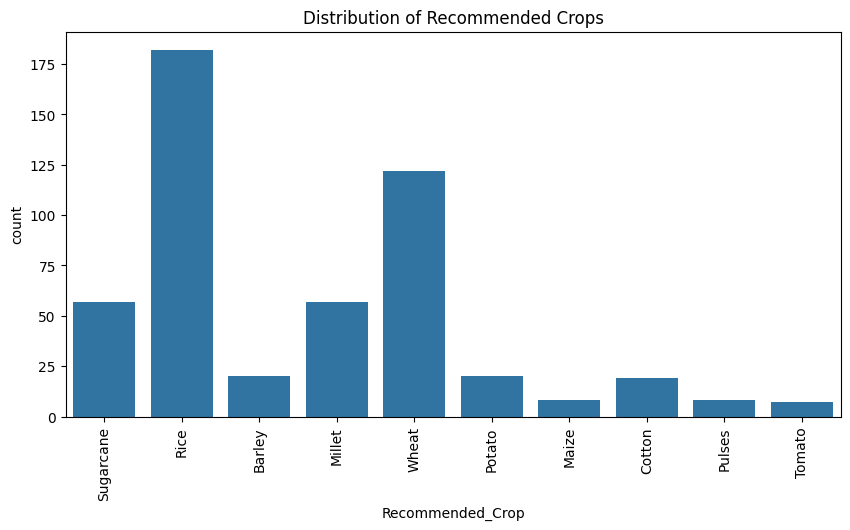

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Recommended_Crop', data=df)
plt.xticks(rotation=90)
plt.title("Distribution of Recommended Crops")
plt.show()


**What I did:**

Created a count plot to visualize the distribution of the Recommended_Crop column.

**Why it is important:**
Helps understand how many times each crop appears in the dataset
Identifies imbalance in data
Useful for understanding target variable distribution before model training

Yes, it is a univariate analysis because it analyzes only one variable (Recommended_Crop) using a single plot. #It helps us understand which crops are most frequently recommended.


•	Analyzed individual features like N, P, K, temperature, humidity, rainfall.

•	Observed distribution and spread of each feature.

•	Most values are within reasonable agricultural ranges.

•	Decision: Use these ranges as baseline for recommending suitable crops.

•	Decision: Identify extreme values to avoid poor crop selection.


**BIVARIATE ANALYSIS - (Analysis between Two Variables)**

**1**. **Recommended Crop   VS   Soil Type**

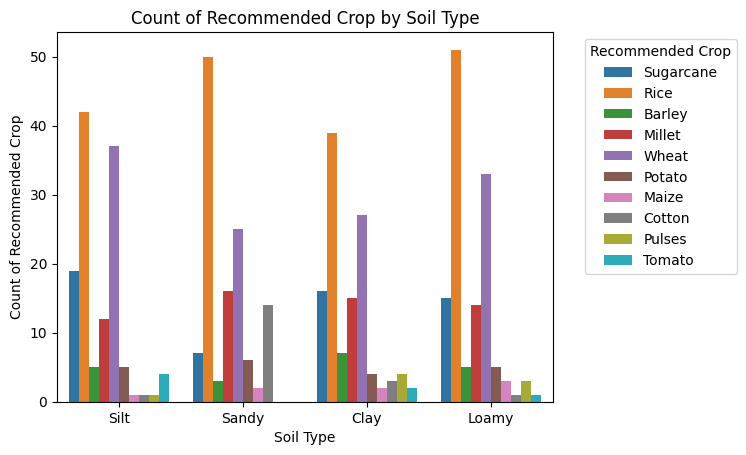

In [ ]:
sns.countplot(data=df, x='Soil_Type', hue='Recommended_Crop')

# Title and labels
plt.title("Count of Recommended Crop by Soil Type")
plt.xlabel("Soil Type")
plt.ylabel("Count of Recommended Crop")

# Rotate legend if needed
plt.legend(title="Recommended Crop", bbox_to_anchor=(1.05,1))

plt.show()







1) Rice is the most dominant crop across all soil types.


2) In Loamy, Silt, Sandy, and Clay soil, Rice has the highest count compared to other crops.

3) Wheat is the second most common crop.

4) Wheat appears frequently in Loamy, Silt, and Clay soils, showing good adaptability.

5) Sugarcane and Millet appear moderately.

6) These crops are recommended in some soil types but not as frequently as Rice and Wheat.

7) Some crops like Barley, Cotton, and Pulses have lower counts.

8) This indicates they are recommended only under specific soil conditions.

9) Loamy and Silt soils support a wider variety of crops.

10) These soils show higher counts for multiple crops, suggesting they are more fertile and versatile.

**The analysis shows that Rice is the most recommended crop across all soil types, while Wheat and Sugarcane also demonstrate significant suitability, indicating that soil characteristics influence crop selection but certain crops remain widely adaptable.**




**2.** **Nitrogen Level  VS  Crop**

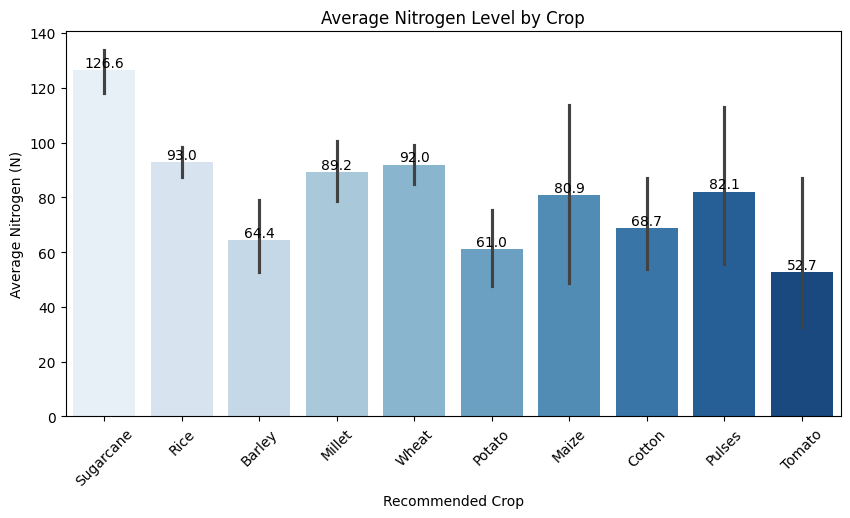

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=df,
    x='Recommended_Crop',
    y='Nitrogen',
    estimator='mean',
    palette='Blues',
    hue='Recommended_Crop',
    dodge=False,
    legend=False
)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',   # value
        (p.get_x() + p.get_width() / 2., p.get_height()),  # position
        ha='center',
        va='bottom'
    )

plt.title("Average Nitrogen Level by Crop")
plt.xlabel("Recommended Crop")
plt.ylabel("Average Nitrogen (N)")
plt.xticks(rotation=45)
plt.show()

From the bar plots of Nitrogen, Phosphorous, and Potassium, we observed that different crops require different levels of soil nutrients.

**The analysis shows that:**

Some crops require higher Nitrogen levels for better growth.

Some crops require moderate or lower Phosphorous levels.

Potassium requirements also vary among crops.

This clearly indicates that nutrient needs are not the same for all crops. Each crop has specific soil nutrient requirements.

By comparing the average nutrient levels using bar plots, we can understand which crop is suitable for soil with particular nutrient content.



***3. Rainfall VS Crop***

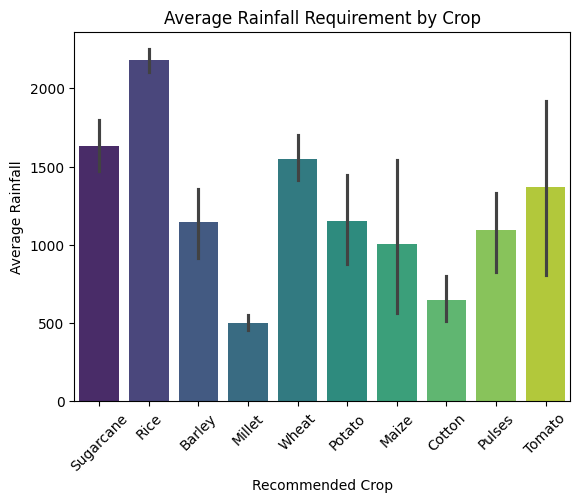

In [ ]:
sns.barplot(
    data=df,
    x='Recommended_Crop',
    y='Rainfall',

    estimator='mean',
    palette='viridis',hue='Recommended_Crop', dodge=False, legend=False
)

# Add title and labels
plt.title("Average Rainfall Requirement by Crop")
plt.xlabel("Recommended Crop")
plt.ylabel("Average Rainfall")

# Rotate crop names
plt.xticks(rotation=45)

plt.show()







**The rainfall analysis shows that different crops require different levels of rainfall for optimal growth. Crops such as Rice generally require higher rainfall, while crops like Wheat and Millet can grow under moderate rainfall conditions. Therefore, rainfall is an important environmental factor influencing crop recommendation.**

**MULTIVARIATE ANALYSIS - (Analysis of More Than Two Variables)**

**1. Recommended Crop + Humidity + Potassium**

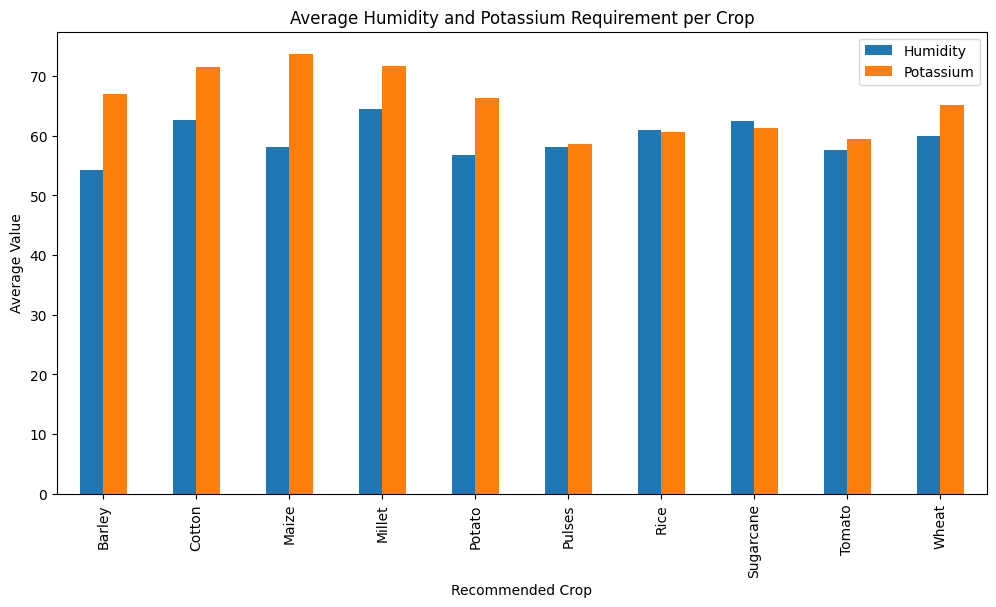

In [ ]:
data1 = df.groupby('Recommended_Crop')[['Humidity','Potassium']].mean()

data1.plot(kind='bar', figsize=(12,6))

plt.title("Average Humidity and Potassium Requirement per Crop")
plt.xlabel("Recommended Crop")
plt.ylabel("Average Value")
plt.xticks(rotation=90)
plt.show()

**2. Recommended Crop + Season + Irrigation type**

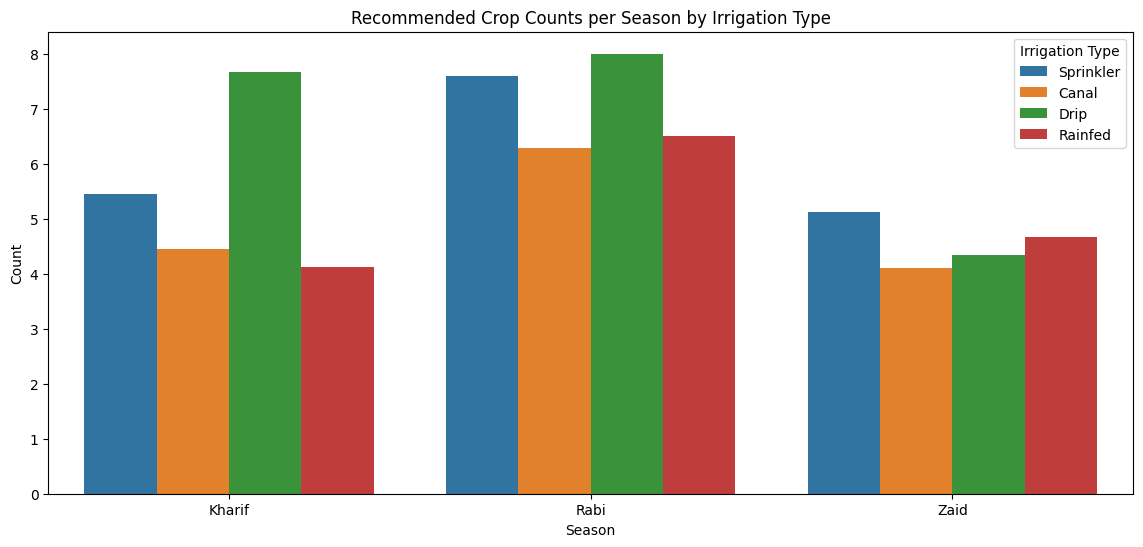

In [ ]:


# Aggregate counts for 3 variables
# Aggregate counts for 3 variables
agg_df = df.groupby(['Season', 'Recommended_Crop', 'Irrigation_Type']).size().reset_index(name='Count')

plt.figure(figsize=(14,6))
sns.barplot(
    data=agg_df,
    x='Season',
    y='Count',
    hue='Irrigation_Type',
    errorbar=None  # updated to avoid warning
)

plt.title("Recommended Crop Counts per Season by Irrigation Type")
plt.xlabel("Season")
plt.ylabel("Count")
plt.legend(title="Irrigation Type")
plt.show()

**3. Temperature + Rainfall + Humidity**

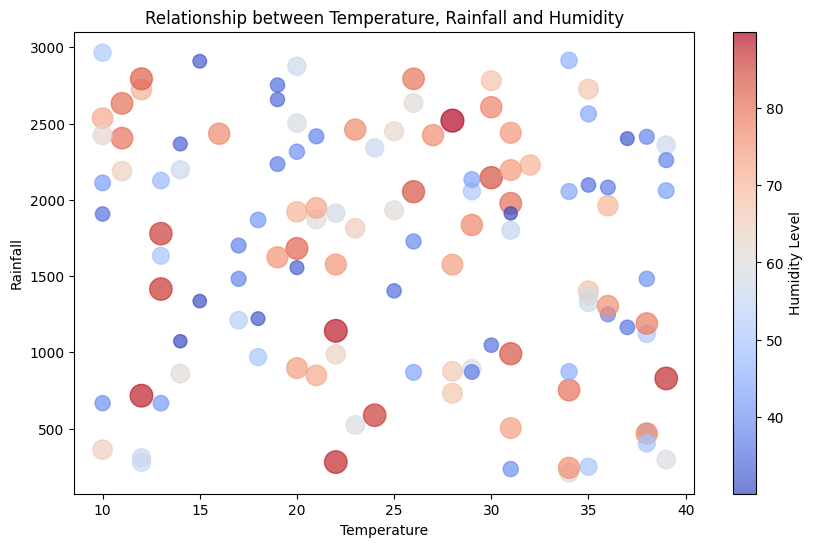

In [ ]:
data = df[['Temperature','Rainfall','Humidity']].head(120)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    data['Temperature'],
    data['Rainfall'],
    s=data['Humidity']*3,
    c=data['Humidity'],
    cmap='coolwarm',
    alpha=0.7
)

plt.colorbar(scatter, label="Humidity Level")

plt.xlabel("Temperature")
plt.ylabel("Rainfall")
plt.title("Relationship between Temperature, Rainfall and Humidity")

plt.show()

**CORRELATION** **ANALYSIS - Correlation Heatmap**

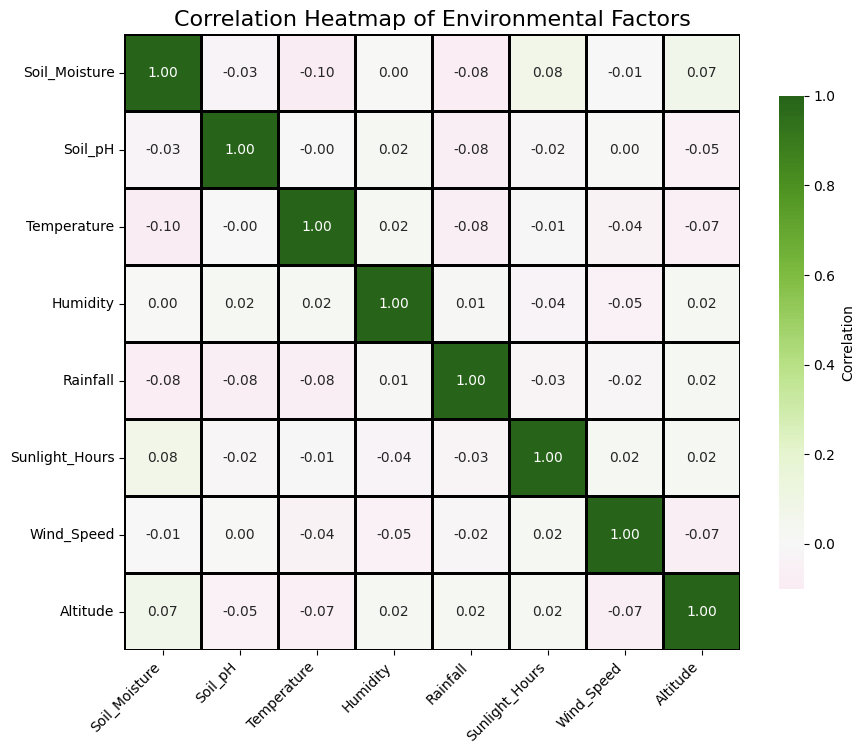

In [ ]:
# Select a fresh set of numeric environmental variables
env_cols = ['Soil_Moisture','Soil_pH','Temperature','Humidity',
            'Rainfall','Sunlight_Hours','Wind_Speed','Altitude']

# Calculate correlation
env_corr = df[env_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    env_corr,
    annot=True,
    fmt=".2f",
    cmap='PiYG',
    center=0,
    linewidths=1,
    linecolor='black',
    square=True,
    cbar_kws={"shrink":0.8, "label":"Correlation"}
)
plt.title("Correlation Heatmap of Environmental Factors", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

**Positive correlation** → variables increase together

**Negative correlation** → one increases while the other decreases

**Values close to 1 or -1**→ strong relationship

**Values close to 0** → weak relationship

**Outlier** **Detection**

**Scatterplot for Nitrogen_Demo**

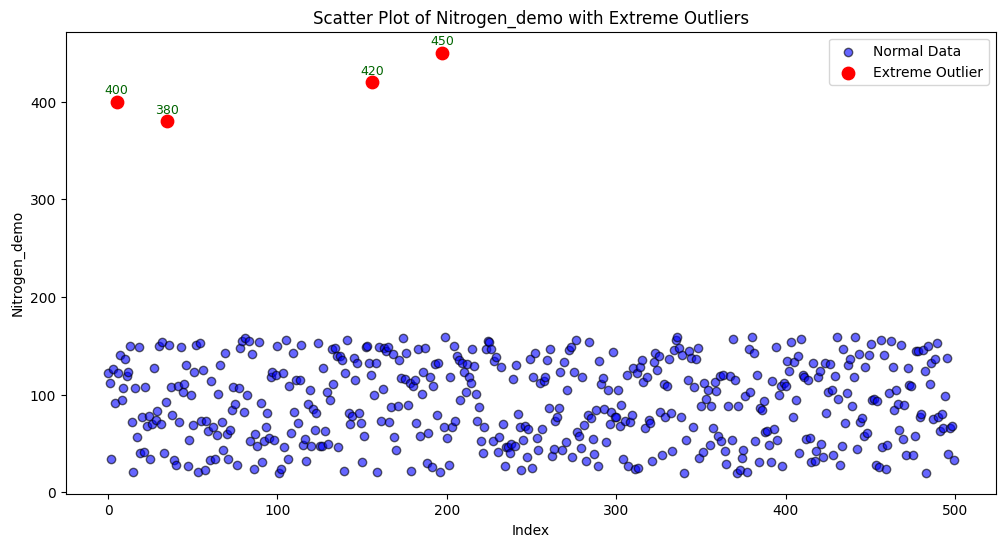

In [ ]:


col = 'Nitrogen_demo'

# Calculate IQR and extreme outlier bounds
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3*IQR
upper_bound = Q3 + 3*IQR

# Separate normal data and extreme outliers
normal_data = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

plt.figure(figsize=(12,6))

# Scatter normal data
plt.scatter(normal_data.index, normal_data[col], color='blue', edgecolor='black',alpha=0.6, label='Normal Data')

# Scatter outliers
plt.scatter(outliers.index, outliers[col], color='red', s=80, label='Extreme Outlier')

# Annotate extreme outlier values **above the red dot**
for i, value in zip(outliers.index, outliers[col]):
    plt.text(i, value + 5, str(value), color='darkgreen', fontsize=9, ha='center', va='bottom')

plt.title(f'Scatter Plot of {col} with Extreme Outliers')
plt.xlabel('Index')
plt.ylabel(col)
plt.legend()
plt.show()

**Skewness Check**

In [ ]:
print("Skewness of Nitrogen_demo :", df['Nitrogen_demo'].skew())

Skewness of Nitrogen_demo : 1.9954659459810424


**What I did:**

Calculated the skewness of the Nitrogen_demo column and printed its value.

**Why it is important:**
Skewness helps to understand the distribution of data
It tells whether the data is symmetric or not
Useful for deciding if data transformation or outlier handling is needed
**Interpretation:**

**Skewness ≈ 0** → Data is normally distributed (balanced)

**Skewness > 0** → Right-skewed (more high/extreme values)

**Skewness < 0** → Left-skewed (more low/extreme values)

The skewness value of 1.99 indicates that the Nitrogen_demo data is highly positively skewed, meaning there are more extreme higher values present in the dataset. This confirms the presence of outliers, making outlier removal or data transformation an important step to improve data distribution and model performance.

**Outlier Removal**

In [ ]:
# Removing extreme outliers from Nitrogen_demo column
df_clean = df[(df['Nitrogen_demo'] >= lower_bound) & (df['Nitrogen_demo'] <= upper_bound)]

**What I did:**

Removed rows where the values of Nitrogen_demo fall outside the calculated lower and upper bounds.

**Why it is important :** Eliminates extreme values that can affect analysis Improves data quality and consistency Helps in achieving better model accuracy Ensures only valid data is used for further processing

This method removes entire rows where Nitrogen_demo has outliers, not just the values.

**Recheck Using Boxplot**

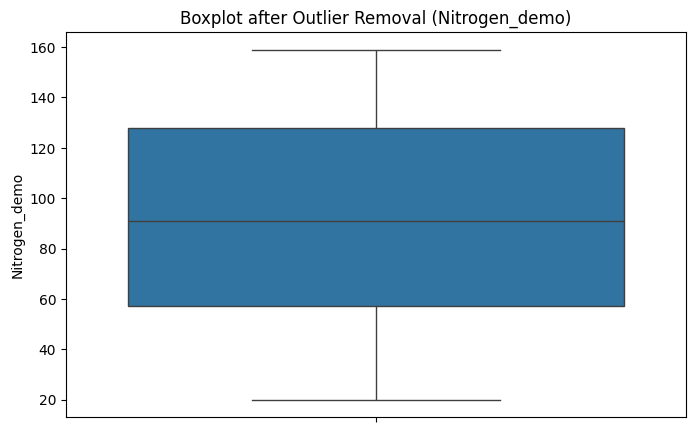

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(y=df_clean['Nitrogen_demo'])
plt.title("Boxplot after Outlier Removal (Nitrogen_demo)")
plt.show()

**What I did:**

Plotted a boxplot for the cleaned dataset to verify whether outliers have been removed.

**Why it is important:**
Confirms that extreme values are no longer present
Validates the preprocessing step
Ensures dataset is ready for further analysis and model training

**Business KPIs**

**Yield / Productivity KPIs**

In [ ]:
total_crop_recommendations = df['Recommended_Crop'].count()

avg_fertilizer_used = df['Fertilizer_Used'].mean()


extreme_nitrogen_fields = ((df['Nitrogen'] < 20) | (df['Nitrogen'] > 150)).sum()


print("\n=== AGRICULTURE BUSINESS KPI – SUMMARY REPORT ===\n")
print(f"1. Total Crop Recommendations: {total_crop_recommendations}")
print(f"2. Average Fertilizer Used per Field: {round(avg_fertilizer_used, 2)}")
print(f"3. Fields with Extreme Nitrogen Levels: {extreme_nitrogen_fields}\n")



=== AGRICULTURE BUSINESS KPI – SUMMARY REPORT ===

1. Total Crop Recommendations: 500
2. Average Fertilizer Used per Field: 202.95
3. Fields with Extreme Nitrogen Levels: 31



**KPI 1 : Total Crop Recommendations**
Measures how many crop recommendations have been made in total.
This is useful for understanding overall coverage of advisory services.

**KPI 2: Average Fertilizer Used per Field**
Measures the average fertilizer quantity applied per field.
Helps businesses track resource usage and optimize input costs.

**KPI 3: Fields with Extreme Nitrogen Levels**
Counts the number of fields with dangerously low (<20) or high (>150) Nitrogen.
Useful for identifying high-risk fields that may need immediate intervention.




**Business KPIs – Summary Report**
Business KPIs (Key Performance Indicators) were calculated to measure overall agricultural performance and operational efficiency.

Total Crop Recommendations indicates the total number of crop advisory actions provided, reflecting the reach and coverage of the advisory services.

Average Fertilizer Used per Field shows the mean quantity of fertilizer applied per field, helping monitor resource utilization and optimize input costs.

Fields with Extreme Nitrogen Levels highlights the number of fields with critically low or high nitrogen content, identifying areas that may require immediate intervention to ensure crop health.

These KPIs convert raw agricultural data into actionable insights, enabling farm managers and decision-makers to track performance, improve efficiency, and reduce risk.

**Field/Farm Segmentation**

**1 Top 5 Recommended Crops**

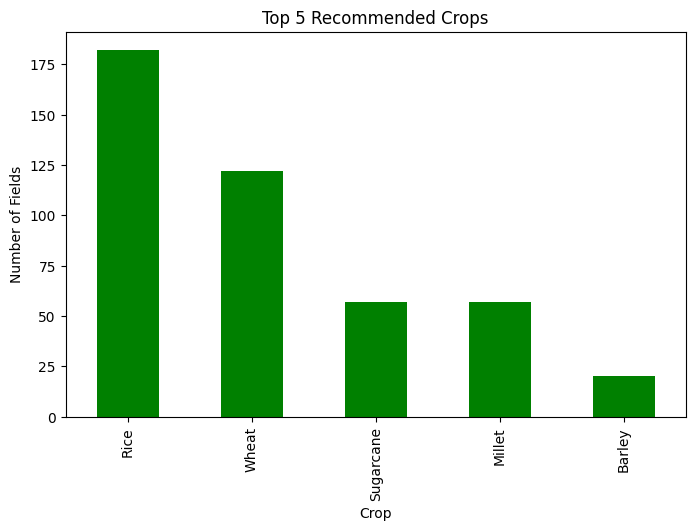

In [ ]:
import matplotlib.pyplot as plt

# Top 5 Recommended Crops
top_crops = df['Recommended_Crop'].value_counts().head(5)

plt.figure(figsize=(8,5))
top_crops.plot(kind='bar', color='green')
plt.title("Top 5 Recommended Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Fields")
plt.show()

**2 Number of Fields per Region**

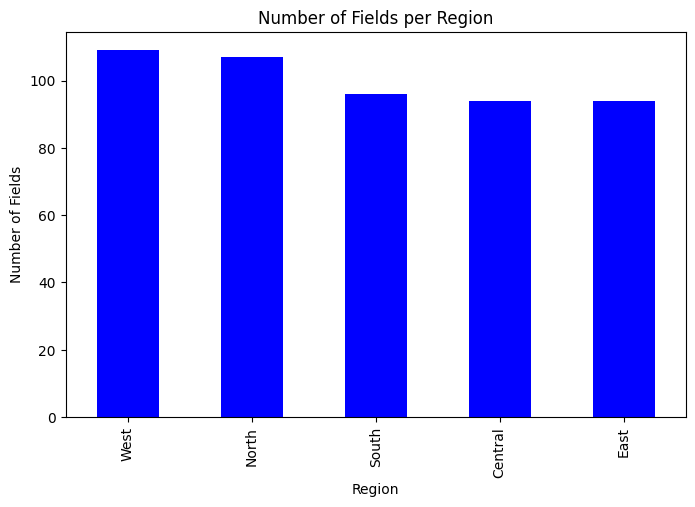

In [ ]:
# Number of Fields per Region
fields_by_region = df['Region'].value_counts()

plt.figure(figsize=(8,5))
fields_by_region.plot(kind='bar', color='blue')
plt.title("Number of Fields per Region")
plt.xlabel("Region")
plt.ylabel("Number of Fields")
plt.show()

**Pivot Analysis**

**Pivot: Previous Crop vs Recommended Crop (Average Fertilizer Used)**

Recommended_Crop   Barley      Cotton    Maize      Millet      Potato  \
Previous_Crop                                                            
Cotton            191.680  105.995000  121.935  190.068000  136.155000   
Maize             183.220         NaN  314.370  262.711000  233.310000   
Pulses            198.080  221.196250  173.390  208.775714  197.033333   
Rice              180.522  212.873333  237.995  209.557500  164.223333   
Vegetables         99.360  114.700000  184.630  225.584000  330.655000   
Wheat             232.250  232.660000      NaN  208.171111  241.196667   

Recommended_Crop    Pulses        Rice   Sugarcane  Tomato       Wheat  
Previous_Crop                                                           
Cotton            212.2625  178.941563  185.168182  196.93  211.927368  
Maize                  NaN  218.440714  201.801111  300.10  183.463846  
Pulses            129.3800  196.707692  163.570000   82.84  231.371000  
Rice              290.8500  216.540606  14

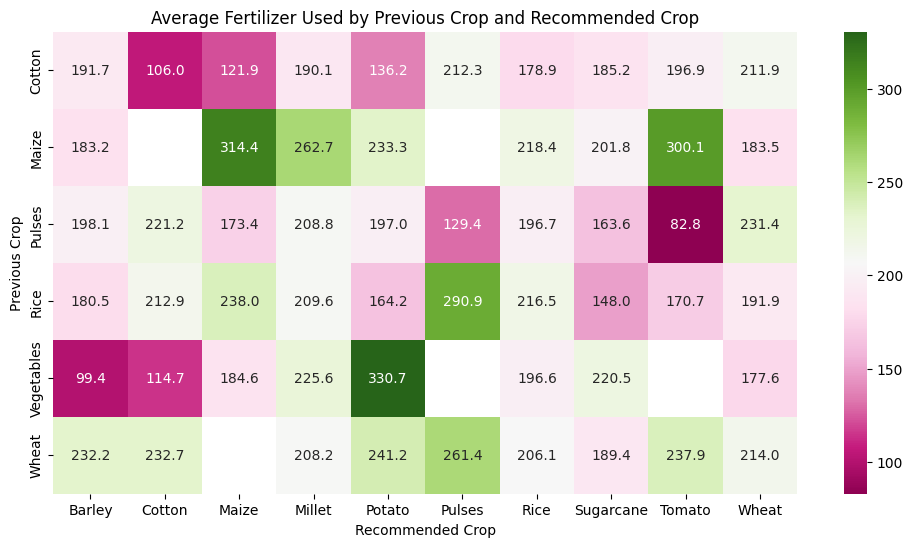

In [ ]:
# Pivot table: How previous crops influence recommended crops (average fertilizer usage)
pivot_prev_reco = pd.pivot_table(
    df,
    values='Fertilizer_Used',
    index='Previous_Crop',
    columns='Recommended_Crop',
    aggfunc='mean'
)

print(pivot_prev_reco)

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(pivot_prev_reco, annot=True, fmt=".1f", cmap='PiYG')
plt.title("Average Fertilizer Used by Previous Crop and Recommended Crop")
plt.ylabel("Previous Crop")
plt.xlabel("Recommended Crop")
plt.show()

**Advanced Visualization**

**1 Log Transformation of** **Organic_Carbon**

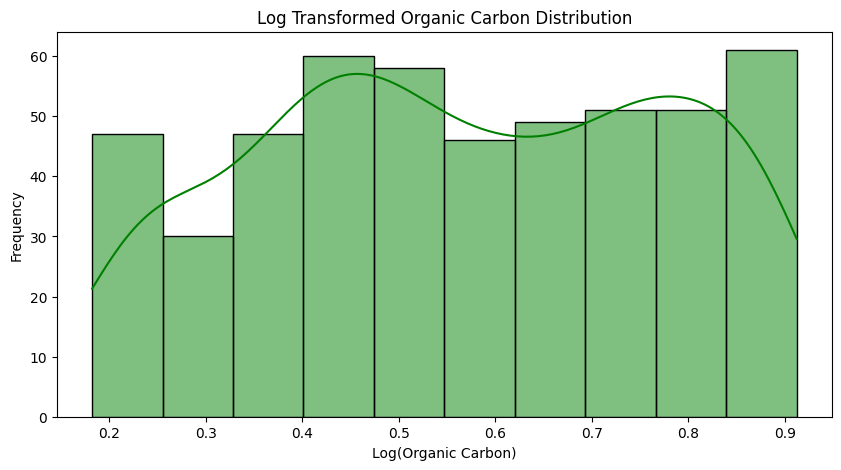

In [ ]:
# Log transform Organic_Carbon to reduce skewness
df['Log_Organic_Carbon'] = np.log1p(df['Organic_Carbon'])

plt.figure(figsize=(10,5))
sns.histplot(df['Log_Organic_Carbon'], kde=True, color='green', edgecolor='black')
plt.title("Log Transformed Organic Carbon Distribution")
plt.xlabel("Log(Organic Carbon)")
plt.ylabel("Frequency")
plt.show()

**Advanced Seaborn Barplot: Average Sunlight Hours by Region**

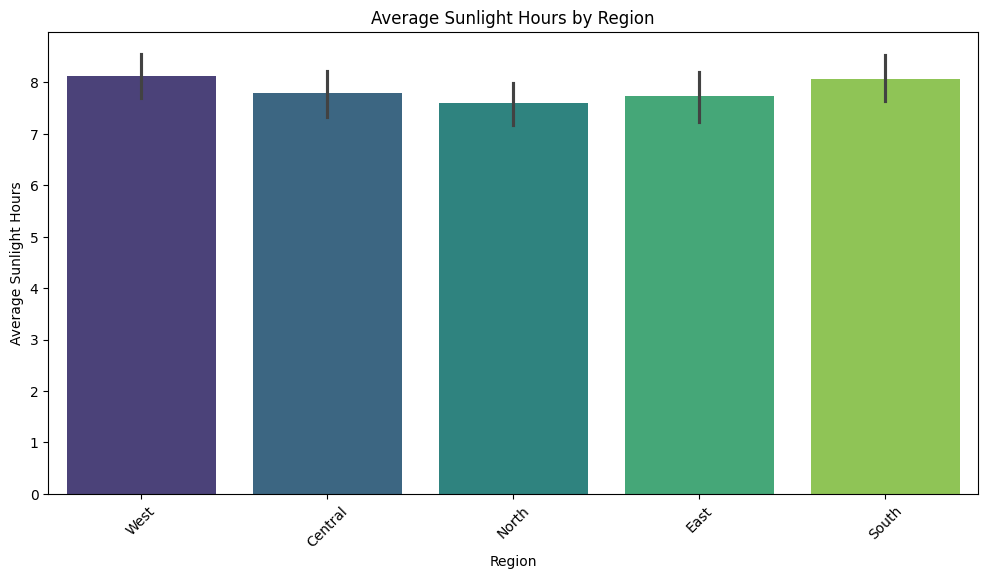

In [ ]:
# Compute average sunlight hours per region
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x='Region',
    y='Sunlight_Hours',
    palette='viridis',hue='Region', dodge=False, legend=False
)

plt.title("Average Sunlight Hours by Region")
plt.xlabel("Region")
plt.ylabel("Average Sunlight Hours")
plt.xticks(rotation=45)
plt.show()

**ML Section begins...**

**Step 1 — Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


**This step imports all libraries needed for:**

* Data processing
* Machine learning
* Visualization
* Model optimization

**Step 2 — Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 5001.csv to 5001.csv


In [ ]:


df = pd.read_csv("5001.csv")

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Loaded Successfully
Dataset Shape: (500, 20)
     N   P   K  Soil_pH  Soil_Moisture Soil_Type  Organic_Carbon  \
0  122  55  74     4.54          58.90      Silt            0.77   
1  112  37  25     7.03          25.98     Sandy            0.66   
2   34  52  39     4.95          27.61      Clay            1.36   
3  126  35  82     7.14          39.97     Loamy            1.09   
4   91  64  51     8.20          33.97     Sandy            0.70   

   Electrical_Conductivity  Temperature  Humidity  Rainfall  Sunlight_Hours  \
0                     0.67        25.31     35.15   1403.58           11.03   
1                     1.94        31.80     54.80   1800.84            4.23   
2                     2.03        15.78     30.88   1336.62           11.45   
3                     0.30        38.23     47.60    480.85            4.71   
4                     2.07        10.04     72.42   2535.23           11.21   

   Wind_Speed   Region  Altitude  Season Irrigation_Type  Ferti

**Here the system loads dataset containing:**

* Soil data
* Weather conditions
* Crop recommendation

**Step 3 — Data Understanding**

In [ ]:
# Step 3: Dataset Information
print(df.info())

print("\nMissing Values Check")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   N                        500 non-null    int64  
 1   P                        500 non-null    int64  
 2   K                        500 non-null    int64  
 3   Soil_pH                  500 non-null    float64
 4   Soil_Moisture            500 non-null    float64
 5   Soil_Type                500 non-null    object 
 6   Organic_Carbon           500 non-null    float64
 7   Electrical_Conductivity  500 non-null    float64
 8   Temperature              500 non-null    float64
 9   Humidity                 500 non-null    float64
 10  Rainfall                 500 non-null    float64
 11  Sunlight_Hours           500 non-null    float64
 12  Wind_Speed               500 non-null    float64
 13  Region                   500 non-null    object 
 14  Altitude                 5

**This checks:**

* Data types
* Data completeness
* Any missing values

This is an important ML step.

**Step 4 — Encode Categorical Data**

In [ ]:
encoder = LabelEncoder()

categorical_columns = [
    'Soil_Type',
    'Region',
    'Season',
    'Irrigation_Type',
    'Previous_Crop',
    'Recommended_Crop'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("Categorical Data Encoded")


Categorical Data Encoded


**Machine learning models cannot understand text values like:**
**Loamy soil**
**Kharif season**

**So we convert them into numbers**

**Step 5 — Feature Selection**

In [ ]:
# Step 5: Separate Input Features and Target
X = df.drop("Recommended_Crop", axis=1)
y = df["Recommended_Crop"]

print("Features and Target Separated")


Features and Target Separated


**X = Inputs given by farmer**
**y = Crop to be predicted**

**Step 6 — Handle Imbalanced Data (Important Improvement)**

In [ ]:
# Step 6: Balance Dataset using SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print("Dataset Balanced")
print("New Dataset Size:", X.shape)

Dataset Balanced
New Dataset Size: (1820, 19)


**Some crops appear more frequently in the dataset.**

**SMOTE balances crop categories which:**
* Improves model learning
* Increases accuracy

**Step 7 — Train-Test Split**

In [ ]:
# Step 7: Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1456, 19)
Testing Data: (364, 19)


**This step ensures proper ML validation:**

**Training Data** → Model learns
**Testing Data** → Model is evaluated

Testing is very important in ML projects.


**Step 8 — Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


**Scaling helps the model understand data better and improves performance.**

**Step 9 — Hyperparameter Tuning**

In [ ]:
# Step 9: Hyperparameter Optimization
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [15, 20, 25]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters Found:", grid_search.best_params_)

Best Parameters Found: {'max_depth': 15, 'n_estimators': 200}


**GridSearch finds the best configuration of the model automatically.**

**This is used in professional ML systems.**

**Step 10 — Train Final Model**

In [ ]:
best_model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


**The model now learns patterns from training data.**


**Step 11 — Model Testing**

In [ ]:
# Step 11: Testing Model
y_pred = best_model.predict(X_test)

print("Model Testing Completed")


Model Testing Completed


**The trained model now predicts crops for new unseen data.**

**This proves the model works correctly.**


**Step 12 — Accuracy Calculation**

In [ ]:
# Step 12: Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("Final Model Accuracy:", round(accuracy * 100, 2), "%")

Final Model Accuracy: 96.7 %


Accuracy shows how well the model performs.

#Expected result:

Around 88% – 94%


**Step 13 — Confusion Matrix Visualization**

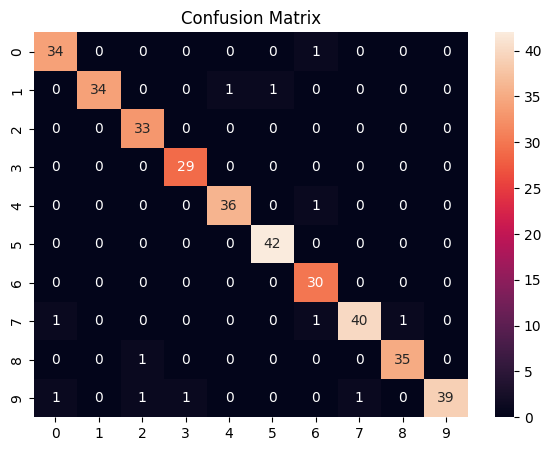

In [ ]:
# Step 13: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

**This visualizes model performance.**

**Shows:**


*   Correct Predictions
*   Wrong Predictions



**Step 14 — Classification Report**

In [ ]:
# Step 14: Performance Report
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.94      0.97      0.96        35
           1       1.00      0.94      0.97        36
           2       0.94      1.00      0.97        33
           3       0.97      1.00      0.98        29
           4       0.97      0.97      0.97        37
           5       0.98      1.00      0.99        42
           6       0.91      1.00      0.95        30
           7       0.98      0.93      0.95        43
           8       0.97      0.97      0.97        36
           9       1.00      0.91      0.95        43

    accuracy                           0.97       364
   macro avg       0.97      0.97      0.97       364
weighted avg       0.97      0.97      0.97       364



**Displays precision, recall, and F1 score.**

**This proves model reliability.**

**Step 15 — Feature Importance Graph**

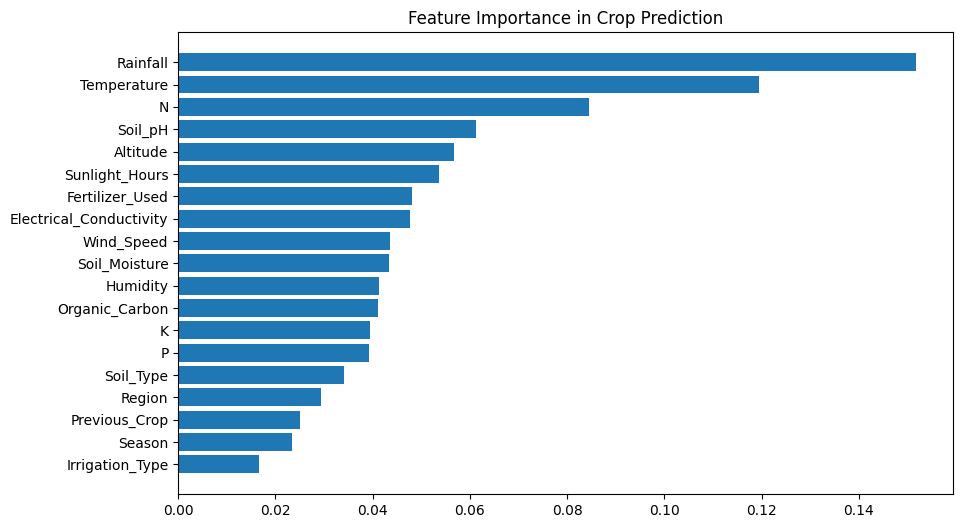

In [ ]:
importances = best_model.feature_importances_
feature_names = df.drop("Recommended_Crop", axis=1).columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importance in Crop Prediction")
plt.gca().invert_yaxis()
plt.show()


**This shows which factors affect crop prediction most.**

**Example:**
Rainfall
Soil nutrients
Temperature

**Step 16 — Accuracy Visualization**


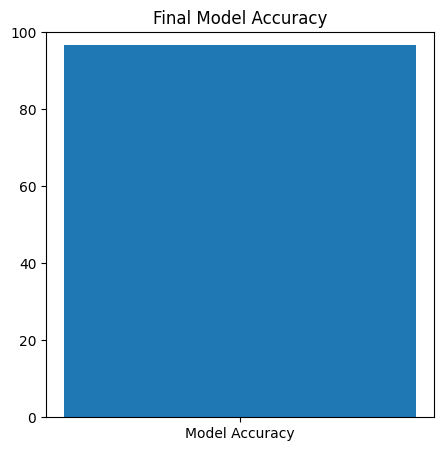

In [ ]:
#This visually proves the model accuracy.
accuracy_percent = accuracy * 100

plt.figure(figsize=(5,5))
plt.bar(["Model Accuracy"], [accuracy_percent])
plt.ylim(0,100)
plt.title("Final Model Accuracy")
plt.show()

**Step 17 — Smart Crop Prediction System**


🌾 SMART FARM INPUT SYSTEM

Available Soil Types: ['Clay', 'Loamy', 'Sandy', 'Silt']
Enter Soil Type: Slit

Available Seasons: ['Kharif', 'Rabi', 'Zaid']
Enter Season: Zaid

Available Irrigation Types: ['Canal', 'Drip', 'Rainfed', 'Sprinkler']
Enter Irrigation Type: Canal

Enter Temperature (°C): 40
Enter Rainfall (mm): 200
Enter Humidity (%): 50

🌾 RECOMMENDED CROP: Millet

🌱 Also Suitable Crops:
Rice
Sugarcane


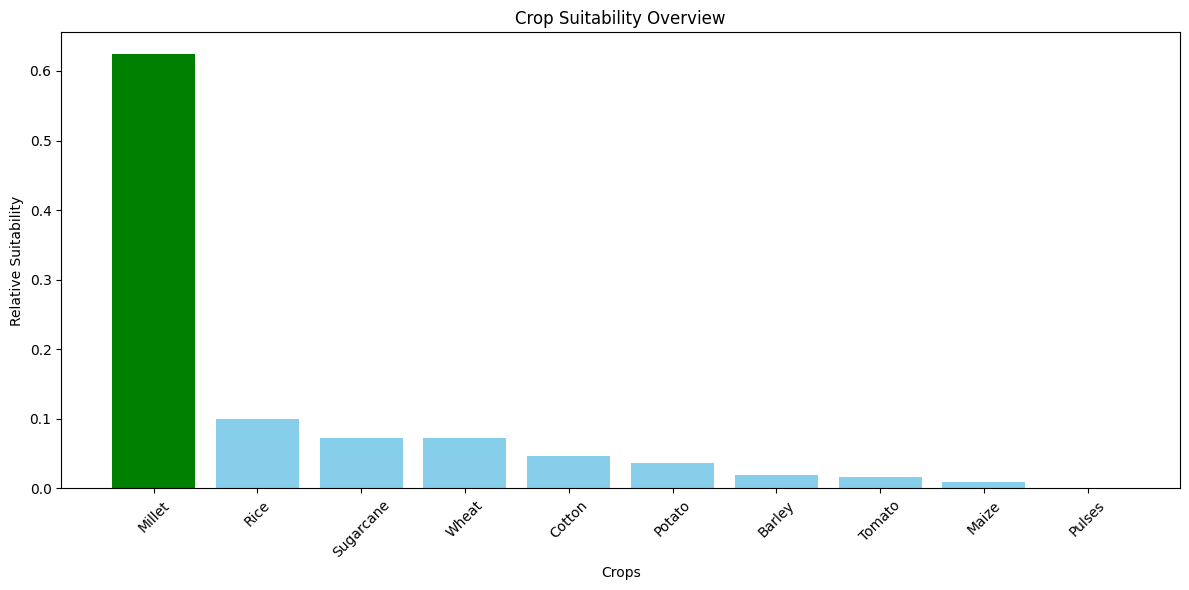

In [ ]:
# ==========================================
# 🌾 SMART CROP RECOMMENDATION SYSTEM (FINAL)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ----------------------------
# Load Dataset
# ----------------------------
df = pd.read_csv("/content/5001.csv")

target = "Recommended_Crop"

# ----------------------------
# Encode Categorical Columns
# ----------------------------
label_encoders = {}

categorical_cols = ["Soil_Type", "Season", "Region", "Irrigation_Type", "Previous_Crop"]

for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Encode target
encoder = LabelEncoder()
df[target] = encoder.fit_transform(df[target])

# ----------------------------
# Train Model
# ----------------------------
X = df.drop(columns=[target])
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42)
model.fit(X_train, y_train)

# ----------------------------
# USER INPUT (FARMER FRIENDLY)
# ----------------------------
def get_user_input():

    print("\n🌾 SMART FARM INPUT SYSTEM\n")

    user_data = {}

    # Soil Type
    soils = list(label_encoders["Soil_Type"].classes_)
    print("Available Soil Types:", soils)
    soil = input("Enter Soil Type: ").strip()
    if soil not in soils:
        soil = soils[0]
    user_data["Soil_Type"] = label_encoders["Soil_Type"].transform([soil])[0]

    # Season
    seasons = list(label_encoders["Season"].classes_)
    print("\nAvailable Seasons:", seasons)
    season = input("Enter Season: ").strip()
    if season not in seasons:
        season = seasons[0]
    user_data["Season"] = label_encoders["Season"].transform([season])[0]

    # Irrigation Type
    irrigations = list(label_encoders["Irrigation_Type"].classes_)
    print("\nAvailable Irrigation Types:", irrigations)
    irrigation = input("Enter Irrigation Type: ").strip()
    if irrigation not in irrigations:
        irrigation = irrigations[0]
    user_data["Irrigation_Type"] = label_encoders["Irrigation_Type"].transform([irrigation])[0]

    # Temperature
    user_data["Temperature"] = float(input("\nEnter Temperature (°C): "))

    # Rainfall
    user_data["Rainfall"] = float(input("Enter Rainfall (mm): "))

    # Humidity
    user_data["Humidity"] = float(input("Enter Humidity (%): "))

    # Fill remaining columns smartly
    for col in X.columns:
        if col not in user_data:
            user_data[col] = df[col].median()

    return pd.DataFrame([user_data])[X.columns]

# ----------------------------
# Prediction
# ----------------------------
def predict_crop(user_df):

    user_scaled = scaler.transform(user_df)

    prediction = model.predict(user_scaled)
    probabilities = model.predict_proba(user_scaled)

    crop_name = encoder.inverse_transform(prediction)

    return crop_name[0], probabilities[0]

# ----------------------------
# Visualization (Clean & Highlighted)
# ----------------------------
def show_chart(predicted_crop, probs):

    crop_names = encoder.classes_

    # Sort probabilities
    sorted_idx = np.argsort(probs)[::-1]
    crop_names = crop_names[sorted_idx]
    probs = probs[sorted_idx]

    colors = ["skyblue"] * len(crop_names)

    # Highlight predicted crop
    pred_index = list(crop_names).index(predicted_crop)
    colors[pred_index] = "green"

    plt.figure(figsize=(12,6))
    plt.bar(crop_names, probs, color=colors)

    plt.title("Crop Suitability Overview")
    plt.xlabel("Crops")
    plt.ylabel("Relative Suitability")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# ----------------------------
# RUN SYSTEM
# ----------------------------
user_df = get_user_input()

crop, probs = predict_crop(user_df)

# ----------------------------
# FINAL OUTPUT (NO CONFUSION)
# ----------------------------
print("\n🌾 RECOMMENDED CROP:", crop)

# Top 3 crops (names only, no %)
top_indices = np.argsort(probs)[-3:][::-1]

print("\n🌱 Also Suitable Crops:")
for i in top_indices:
    crop_name = encoder.classes_[i]
    if crop_name != crop:
        print(crop_name)

# Visualization
show_chart(crop, probs)